In [122]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

In [76]:
import importlib
import helpers_louis
importlib.reload(helpers_louis)

<module 'helpers_louis' from '/Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/helpers_louis.py'>

## Main research question
To what extent do students' written responses, feedback quality, and chatbot engagement patterns reflect their level of understanding and predict academic performance?

## Sub-question 1
How do the linguistic and semantic characteristics of students' written responses relate to their performance across essay and text comprehension assessments?

## Part 1 — Essay-based analysis
Can simple linguistic surface features extracted from students' essays predict essay performance?

## First prediction task
We start with a focused regression task on `essay_results.csv`.

- **Input:** essay metadata and engineered features extracted from the raw essay text
- **Target:** an essay assessment score, initially `structure__coherence`
- **Goal:** test whether simple observable linguistic characteristics of essays already carry predictive signal about writing quality

## Why this first step?
This first step provides a clean baseline before moving to:
1. richer semantic text features
2. text comprehension responses from `text_results.csv`
3. a broader comparison across assessment types

In [37]:
# Directory
print("Python working directory:", os.getcwd())

data_dir = './data'
assert os.path.isdir(data_dir), f"File not found: {data_dir}" # check files exist

Python working directory: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026


In [38]:

essay_results = pd.read_csv('{}/essay_results.csv'.format(data_dir))

In [123]:
# dataframe de travail
df_clean = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_clean = df_clean.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

# features engeneering
df_clean["word_count"] = df_clean["text"].apply(helpers_louis.word_count)
df_clean["char_count"] = df_clean["text"].apply(helpers_louis.char_count)
df_clean["sentence_count"] = df_clean["text"].apply(helpers_louis.sentence_count)
df_clean["avg_sentence_length"] = df_clean["text"].apply(helpers_louis.avg_sentence_length)
df_clean["avg_word_length"] = df_clean["text"].apply(helpers_louis.avg_word_length)
df_clean["lexical_diversity"] = df_clean["text"].apply(helpers_louis.lexical_diversity)
df_clean["comma_count"] = df_clean["text"].apply(helpers_louis.comma_count)
df_clean["semicolon_count"] = df_clean["text"].apply(helpers_louis.semicolon_count)
df_clean["colon_count"] = df_clean["text"].apply(helpers_louis.colon_count)
df_clean["exclamation_count"] = df_clean["text"].apply(helpers_louis.exclamation_count)
df_clean["question_count"] = df_clean["text"].apply(helpers_louis.question_count)
df_clean["long_word_ratio"] = df_clean["text"].apply(helpers_louis.long_word_ratio)


# ===== X / y =====
feature_cols = [
    "course",
    "text_type",
    "word_count",
    "char_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "comma_count",
    "semicolon_count",
    "colon_count",
    "exclamation_count",
    "question_count",
    "long_word_ratio",
]

X = df_clean[feature_cols].copy()
y = df_clean["structure__coherence"].copy()

print(df_clean.shape)
print(X.head())
print(y.head())

(10065, 16)
   course   text_type  word_count  char_count  sentence_count  \
0    5447  erzaehlung         491        3048              41   
1    5447  erzaehlung         579        3542              60   
2    5447  erzaehlung         310        1897              25   
3    5447  erzaehlung         582        3686              60   
4    5447  erzaehlung          96         569               4   

   avg_sentence_length  avg_word_length  lexical_diversity  comma_count  \
0             11.97561         4.997963           0.584521           24   
1              9.65000         4.744387           0.426598           37   
2             12.40000         4.948387           0.561290           18   
3              9.70000         4.970790           0.426117           37   
4             24.00000         4.802083           0.750000            9   

   semicolon_count  colon_count  exclamation_count  question_count  \
0                0            1                  3               3   
1     

In [124]:
cat_cols = ["course", "text_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)

mlp_model_clean = Pipeline([
    ("prep", preprocessor),
    ("reg", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

cv_part1 = KFold(n_splits=5, shuffle=True, random_state=42)

In [125]:
cv_scores_part1 = cross_validate(
    mlp_model_clean,
    X,
    y,
    cv=cv_part1,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

y_pred_oof = cross_val_predict(
    mlp_model_clean,
    X,
    y,
    cv=cv_part1,
    n_jobs=-1
)

print("Part 1 - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_part1["test_mae"].mean(), cv_scores_part1["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_part1["test_rmse"].mean(), cv_scores_part1["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_part1["test_r2"].mean(), cv_scores_part1["test_r2"].std()
))

# Fit once on full data to inspect optimization diagnostics like loss_curve_.
mlp_model_clean.fit(X, y)
print("n_iter_ (full fit) =", mlp_model_clean.named_steps["reg"].n_iter_)
print("final_loss (full fit) =", mlp_model_clean.named_steps["reg"].loss_)

Part 1 - 5-fold CV
MAE : 1.0159 +/- 0.0266
RMSE: 1.3798 +/- 0.0951
R2  : 0.2201 +/- 0.1027
n_iter_ (full fit) = 54
final_loss (full fit) = 0.8091740414536658


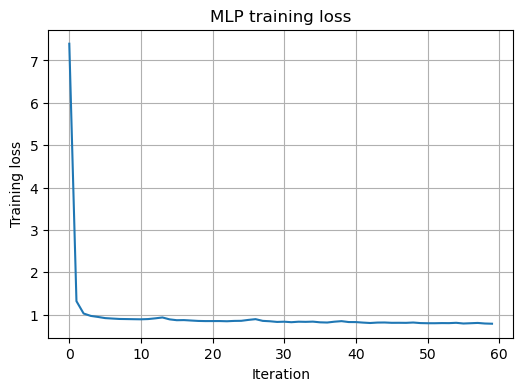

In [55]:

plt.figure(figsize=(6,4))
plt.plot(mlp_model_clean.named_steps["reg"].loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("MLP training loss")
plt.grid(True)
plt.show()

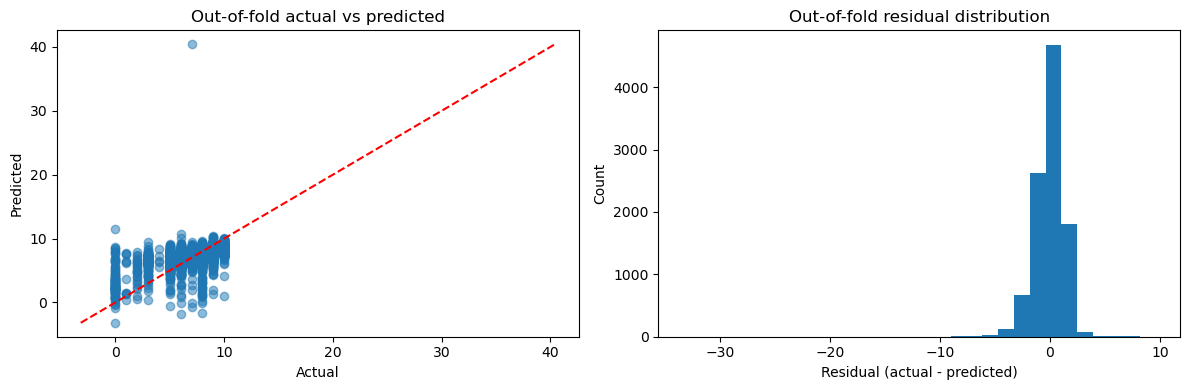

In [126]:
residuals = y - y_pred_oof

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y, y_pred_oof, alpha=0.5)
lims = [min(y.min(), y_pred_oof.min()), max(y.max(), y_pred_oof.max())]
ax[0].plot(lims, lims, "r--")
ax[0].set_title("Out-of-fold actual vs predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

ax[1].hist(residuals, bins=30)
ax[1].set_title("Out-of-fold residual distribution")
ax[1].set_xlabel("Residual (actual - predicted)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [127]:
pred_df = X.copy()
pred_df["y_true"] = y.values
pred_df["y_pred"] = y_pred_oof
pred_df["abs_err"] = np.abs(pred_df["y_true"] - pred_df["y_pred"])

print("Top CV out-of-fold errors by course:")
display(pred_df.groupby("course")["abs_err"].mean().sort_values(ascending=False).head(10))

print("Top CV out-of-fold errors by text_type:")
display(pred_df.groupby("text_type")["abs_err"].mean().sort_values(ascending=False).head(10))

Top CV out-of-fold errors by course:


course
5447    1.034559
3301    0.985407
Name: abs_err, dtype: float64

Top CV out-of-fold errors by text_type:


text_type
bericht         1.046369
beschreibung    1.025552
erzaehlung      1.023348
eroerterung     0.945479
Name: abs_err, dtype: float64

## Interim result for Part 1
Using 5-fold cross-validation, simple engineered surface-level linguistic features show a moderate and consistent predictive signal for the essay score `structure__coherence`.

This indicates that observable properties of the text, such as length, sentence structure, lexical diversity, and punctuation patterns, are genuinely informative for essay coherence, but the predictive strength should not be overstated.

This part remains a useful baseline before testing richer semantic representations.

## Part 2 — Essay analysis with richer semantic features
After building a first baseline with simple surface-level linguistic features, we extend the essay analysis by incorporating richer semantic representations of the text.

We ask the following question:

**Do richer semantic text features improve the prediction of essay performance compared with simple linguistic surface features alone?**

In this second step, we keep the same essay-based setting and the same prediction framework, but we move from basic handcrafted features toward more informative text representations.

The goal is to evaluate whether semantic information contained in students' essays provides additional predictive value for essay assessment outcomes.

In [79]:
german_stopwords = [
    "aber", "als", "am", "an", "auch", "auf", "aus", "bei", "bin", "bis",
    "bist", "da", "dadurch", "daher", "darum", "das", "daß", "dass", "dein",
    "deine", "dem", "den", "der", "des", "dessen", "deshalb", "die", "dies",
    "dieser", "dieses", "doch", "dort", "du", "durch", "ein", "eine", "einem",
    "einen", "einer", "eines", "er", "es", "euer", "eure", "für", "hatte",
    "hatten", "hattest", "hattet", "hier", "hinter", "ich", "ihr", "ihre",
    "im", "in", "ist", "ja", "jede", "jedem", "jeden", "jeder", "jedes",
    "jener", "jenes", "jetzt", "kann", "kannst", "können", "könnt", "machen",
    "mein", "meine", "mit", "muß", "mußt", "musst", "müssen", "müsst",
    "nach", "nachdem", "nein", "nicht", "nun", "oder", "seid", "sein",
    "seine", "sich", "sie", "sind", "soll", "sollen", "sollst", "sollt",
    "sonst", "soweit", "sowie", "und", "unser", "unsere", "unter", "vom",
    "von", "vor", "wann", "warum", "was", "weiter", "weitere", "wenn",
    "wer", "werde", "werden", "werdet", "weshalb", "wie", "wieder", "wieso",
    "wir", "wird", "wirst", "wo", "woher", "wohin", "zu", "zum", "zur",
    "über"
]

In [128]:
# data selection for Part 2
df_semantic = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_semantic = df_semantic.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

df_semantic["text_clean"] = df_semantic["text"].apply(helpers_louis.clean_german_essay_text)

X = df_semantic[["course", "text_type", "text_clean"]].copy()
y = df_semantic["structure__coherence"].copy()

cv_part2 = KFold(n_splits=5, shuffle=True, random_state=42)

In [129]:
#Preprocessing
text_col = "text_clean"
cat_cols = ["course", "text_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                stop_words=german_stopwords,
                ngram_range=(1, 1),
                min_df=3,
                max_df=0.90,
                max_features=5000,
                sublinear_tf=True,
                token_pattern=r"(?u)\b[a-zA-ZäöüÄÖÜß]{2,}\b"
            ),
            text_col
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ],
    remainder="drop"
)


In [130]:
# model
ridge_model = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

In [132]:
# model fitting on full data (for feature inspection)
ridge_model.fit(X, y)

,steps,"[('prep', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [131]:
# model evaluation with cross-validation
cv_scores_part2 = cross_validate(
    ridge_model,
    X,
    y,
    cv=cv_part2,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Part 2 - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_part2["test_mae"].mean(), cv_scores_part2["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_part2["test_rmse"].mean(), cv_scores_part2["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_part2["test_r2"].mean(), cv_scores_part2["test_r2"].std()
))

Part 2 - 5-fold CV
MAE : 0.9211 +/- 0.0164
RMSE: 1.2712 +/- 0.0267
R2  : 0.3406 +/- 0.0062


In [133]:
tfidf = ridge_model.named_steps["prep"].named_transformers_["text"]
feature_names = tfidf.get_feature_names_out()

print("nb text features:", len(feature_names))
print(feature_names[:100])

nb text features: 5000
['aarau' 'ab' 'abend' 'abendessen' 'abends' 'abenteuer' 'aberdeen'
 'abfall' 'abgeben' 'abgelegenen' 'abgelenkt' 'abgemacht' 'abgeschafft'
 'abgeschlossen' 'abgesehen' 'abholen' 'abhängig' 'abkürzung'
 'abkürzungen' 'ablenken' 'ablenkung' 'abrupt' 'abschied' 'abschliessend'
 'abschluss' 'abseits' 'absichtlich' 'absolut' 'abstand' 'ach' 'acht'
 'achten' 'achterbahn' 'achterbahnen' 'achtung' 'adern' 'adjektive'
 'adler' 'adrenalin' 'adresse' 'affe' 'affen' 'ah' 'ahmed' 'ahnte'
 'ahnung' 'aisha' 'akku' 'aktion' 'aktiv' 'aktivitäten' 'akzeptieren'
 'akzeptierte' 'al' 'alarm' 'albtraum' 'alexander' 'alexandra' 'algen'
 'alien' 'aliens' 'alkohol' 'all' 'alle' 'allein' 'alleine' 'allem'
 'allen' 'aller' 'allerbesten' 'allerbester' 'allerdings' 'alles'
 'allgemein' 'alls' 'alltag' 'allzu' 'also' 'alt' 'alte' 'alten' 'alter'
 'alternative' 'alters' 'altes' 'ampeln' 'anblick' 'and' 'andere'
 'anderem' 'anderen' 'anderer' 'andererseits' 'anderes' 'andern' 'anders'
 'anderse

## Interim result for Part 2
With 5-fold cross-validation, the German word-level TF-IDF + Ridge model provides a moderate predictive signal for `structure__coherence`.

Compared with the surface-feature baseline, this representation is not dramatically superior, suggesting that essay coherence depends on both structural writing properties and lexical-semantic information.

Overall, cross-validated results support a balanced interpretation: both feature families are relevant, and model selection should rely on validated performance rather than a single split.

## Part 3 — Comparison of surface and word-based text representations

In this part, we compare the two essay-based modeling approaches developed previously:

- Part 1: simple engineered surface-level linguistic features
- Part 2: word-based text representations using TF-IDF

The goal is to assess which type of representation is more informative for predicting the essay score `structure__coherence`, and to better understand what this reveals about the nature of the target.

This comparison helps determine whether essay coherence is better captured by explicit structural features or by lexical content extracted directly from the text.